# Dự án 1: Phân tích kinh tế vĩ mô và thị trường tài chính

## Mục tiêu
Dự án này tổng hợp lại các kỹ thuật bạn đã học về **merge**, **merge ordered**,
xử lý dữ liệu theo thời gian và trực quan hóa. Bộ notebook tập trung vào 3 câu hỏi:

1. GDP của 4 nền kinh tế lớn (Mỹ, Trung Quốc, Đức, Nhật) thay đổi như thế nào trong giai đoạn 2010-2018?
2. Sau khi ghép GDP với dân số, GDP bình quân đầu người khác nhau ra sao giữa các nước?
3. Với riêng Mỹ, tăng trưởng GDP có đi cùng chiều với lợi suất S&P500 hay không?

## Dữ liệu sử dụng
- `WorldBank_GDP.csv`
- `WorldBank_POP.csv`
- `S&P500.csv`

## Lưu ý về dữ liệu
- File dân số có **bản ghi trùng ở năm 2012**, nên notebook sẽ làm sạch trước khi phân tích.
- Dữ liệu S&P500 hiện chỉ đủ cho giai đoạn 2008-2017 và số quan sát không nhiều, vì vậy phần tương quan chỉ mang tính **khám phá**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlelocation'] = 'left'

DATA_DIR = Path('data')

gdp = pd.read_csv(DATA_DIR / 'WorldBank_GDP.csv')
pop = pd.read_csv(DATA_DIR / 'WorldBank_POP.csv')
sp500 = pd.read_csv(DATA_DIR / 'S&P500.csv').rename(columns={'Date': 'Year', 'Returns': 'SP500_Returns'})

print('Kích thước GDP   :', gdp.shape)
print('Kích thước POP   :', pop.shape)
print('Kích thước S&P500:', sp500.shape)
gdp.head()

Kích thước GDP   : (40, 5)
Kích thước POP   : (2640, 5)
Kích thước S&P500: (10, 2)


,Country Name,Country Code,Indicator Name,Year,GDP
0,China,CHN,GDP (current US$),2010,6.087160e+12
1,Germany,DEU,GDP (current US$),2010,3.417090e+12
2,Japan,JPN,GDP (current US$),2010,5.700100e+12
3,United States,USA,GDP (current US$),2010,1.499210e+13
4,China,CHN,GDP (current US$),2011,7.551500e+12


## 1. Làm sạch và hợp nhất dữ liệu

Bước quan trọng nhất của dự án là kiểm tra chất lượng dữ liệu trước khi merge.
Ở đây, ta sẽ:

- kiểm tra khóa ghép `Country Code` + `Year`
- loại trùng ở bảng dân số
- ghép GDP với dân số để tạo thêm biến **GDP per capita**

In [2]:
gdp_duplicate_keys = (
    gdp.groupby(['Country Code', 'Year'])
       .size()
       .reset_index(name='n')
       .query('n > 1')
)
pop_duplicate_keys = (
    pop.groupby(['Country Code', 'Year'])
       .size()
       .reset_index(name='n')
       .query('n > 1')
)

print('Số khóa bị trùng trong bảng GDP     :', len(gdp_duplicate_keys))
print('Số khóa bị trùng trong bảng dân số  :', len(pop_duplicate_keys))
print('Ví dụ khóa bị trùng ở GDP:')
display(gdp_duplicate_keys.head())
print('Ví dụ khóa bị trùng ở bảng dân số:')
display(pop_duplicate_keys.head())

gdp_clean = gdp.drop_duplicates(subset=['Country Code', 'Year']).copy()
pop_clean = pop.drop_duplicates(subset=['Country Code', 'Year']).copy()
sp500 = sp500.sort_values('Year').reset_index(drop=True)

macro = (
    gdp_clean.merge(
        pop_clean[['Country Code', 'Country Name', 'Year', 'Pop']],
        on=['Country Code', 'Country Name', 'Year'],
        how='left'
    )
    .sort_values(['Country Name', 'Year'])
    .reset_index(drop=True)
)
macro['GDP_per_capita'] = macro['GDP'] / macro['Pop']
macro['GDP_growth_pct'] = macro.groupby('Country Code')['GDP'].pct_change() * 100
macro['Pop_growth_pct'] = macro.groupby('Country Code')['Pop'].pct_change() * 100
macro['GDP_per_capita_growth_pct'] = macro.groupby('Country Code')['GDP_per_capita'].pct_change() * 100

print('Số giá trị thiếu sau khi ghép:')
display(macro.isna().sum().to_frame('missing'))
macro.head(8)

Số khóa bị trùng trong bảng GDP     : 4
Số khóa bị trùng trong bảng dân số  : 264
Ví dụ khóa bị trùng ở GDP:


,Country Code,Year,n
2,CHN,2012,2
11,DEU,2012,2
20,JPN,2012,2
29,USA,2012,2


Ví dụ khóa bị trùng ở bảng dân số:


,Country Code,Year,n
2,ABW,2012,2
11,AFG,2012,2
20,AGO,2012,2
29,ALB,2012,2
38,AND,2012,2


Số giá trị thiếu sau khi ghép:


,missing
Country Name,0
Country Code,0
Indicator Name,0
Year,0
GDP,0
Pop,0
GDP_per_capita,0
GDP_growth_pct,4
Pop_growth_pct,4
GDP_per_capita_growth_pct,4


,Country Name,Country Code,Indicator Name,Year,GDP,Pop,GDP_per_capita,GDP_growth_pct,Pop_growth_pct,GDP_per_capita_growth_pct
0,China,CHN,GDP (current US$),2010,6.087160e+12,1.337705e+09,4550.450211,NaN,NaN,NaN
1,China,CHN,GDP (current US$),2011,7.551500e+12,1.344130e+09,5618.132175,24.056210,0.480300,23.463216
2,China,CHN,GDP (current US$),2012,8.532230e+12,1.350695e+09,6316.918327,12.987221,0.488420,12.438051
3,China,CHN,GDP (current US$),2013,9.570410e+12,1.357380e+09,7050.649044,12.167745,0.494930,11.615327
4,China,CHN,GDP (current US$),2014,1.043850e+13,1.364270e+09,7651.344675,9.070562,0.507596,8.519721
5,China,CHN,GDP (current US$),2015,1.101550e+13,1.371220e+09,8033.357156,5.527614,0.509430,4.992750
6,China,CHN,GDP (current US$),2016,1.113790e+13,1.378665e+09,8078.757349,1.111162,0.542947,0.565146
7,China,CHN,GDP (current US$),2017,1.214350e+13,1.386395e+09,8759.047746,9.028632,0.560687,8.420731


## 2. Xu hướng GDP theo quốc gia

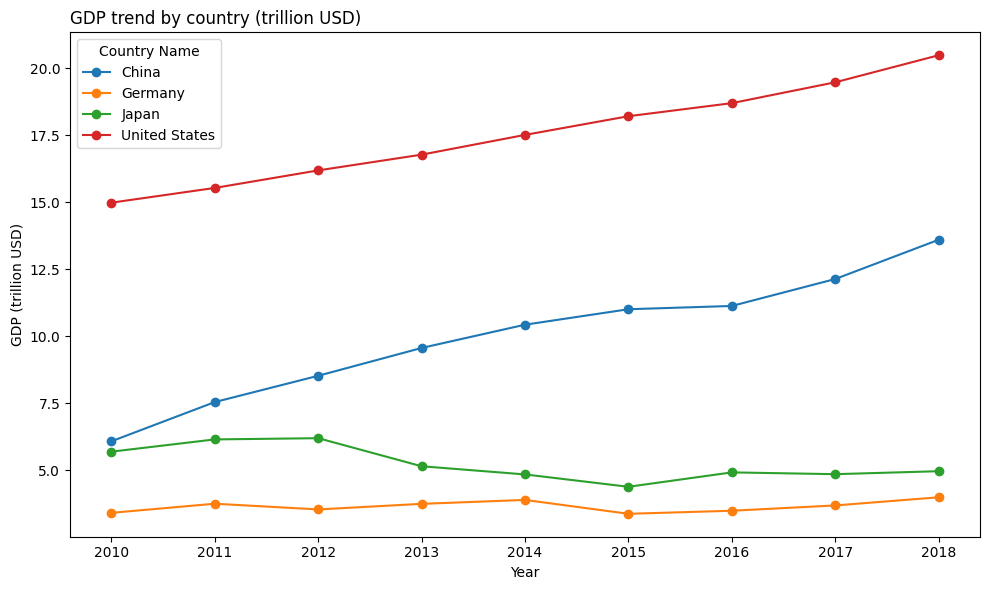

In [3]:
pivot_gdp = macro.pivot(index='Year', columns='Country Name', values='GDP') / 1e12
ax = pivot_gdp.plot(marker='o')
ax.set_title('GDP trend by country (trillion USD)')
ax.set_xlabel('Year')
ax.set_ylabel('GDP (trillion USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. GDP bình quân đầu người

GDP tuyệt đối giúp nhìn quy mô nền kinh tế, nhưng GDP bình quân đầu người cho thấy
mức sản lượng tạo ra bình quân trên mỗi người dân.

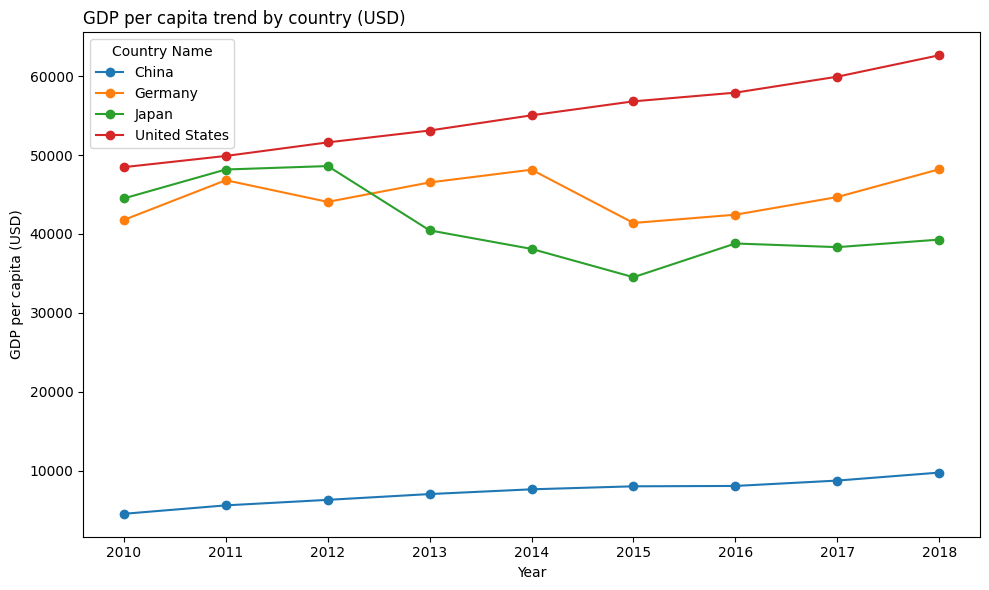

In [4]:
pivot_pc = macro.pivot(index='Year', columns='Country Name', values='GDP_per_capita')
ax = pivot_pc.plot(marker='o')
ax.set_title('GDP per capita trend by country (USD)')
ax.set_xlabel('Year')
ax.set_ylabel('GDP per capita (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Cơ cấu GDP năm 2018 trong nhóm 4 nước

,Country Name,GDP,GDP_share_pct
35,United States,2.049410e+13,47.583259
8,China,1.360820e+13,31.595557
26,Japan,4.970920e+12,11.541496
17,Germany,3.996760e+12,9.279689


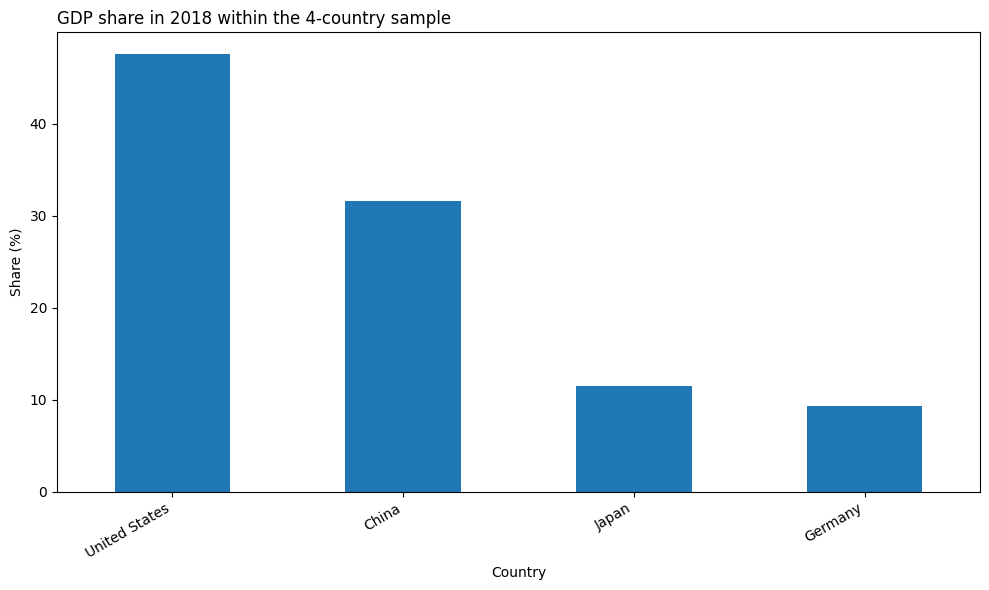

In [5]:
gdp_2018 = macro.loc[macro['Year'] == 2018, ['Country Name', 'GDP']].copy()
gdp_2018['GDP_share_pct'] = gdp_2018['GDP'] / gdp_2018['GDP'].sum() * 100
display(gdp_2018.sort_values('GDP_share_pct', ascending=False))

ax = gdp_2018.sort_values('GDP_share_pct', ascending=False).plot(
    kind='bar', x='Country Name', y='GDP_share_pct', legend=False
)
ax.set_title('GDP share in 2018 within the 4-country sample')
ax.set_xlabel('Country')
ax.set_ylabel('Share (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Mỹ: tăng trưởng GDP và lợi suất S&P500

Vì S&P500 phản ánh thị trường chứng khoán Mỹ, phần dưới đây chỉ giữ lại dữ liệu của Mỹ
rồi ghép với lợi suất S&P500 theo năm.

In [6]:
us = (
    macro.loc[macro['Country Code'] == 'USA', ['Year', 'GDP', 'GDP_per_capita', 'GDP_growth_pct', 'GDP_per_capita_growth_pct']]
         .merge(sp500, on='Year', how='inner')
         .sort_values('Year')
         .reset_index(drop=True)
)

display(us)
display(us[['GDP_growth_pct', 'GDP_per_capita_growth_pct', 'SP500_Returns']].corr())

,Year,GDP,GDP_per_capita,GDP_growth_pct,GDP_per_capita_growth_pct,SP500_Returns
0,2010,1.499210e+13,48466.976201,NaN,NaN,12.78
1,2011,1.554260e+13,49883.174629,3.671934,2.921986,0.00
2,2012,1.619700e+13,51603.473848,4.210364,3.448656,13.41
3,2013,1.678480e+13,53106.754134,3.629067,2.913138,29.60
4,2014,1.752170e+13,55032.811842,4.390282,3.626766,11.39
5,2015,1.821930e+13,56803.479966,3.981349,3.217477,-0.73
6,2016,1.870720e+13,57904.238377,2.677929,1.937836,9.54
7,2017,1.948540e+13,59927.948739,4.159896,3.494926,19.42


,GDP_growth_pct,GDP_per_capita_growth_pct,SP500_Returns
GDP_growth_pct,1.000000,0.998022,0.051596
GDP_per_capita_growth_pct,0.998022,1.000000,0.089495
SP500_Returns,0.051596,0.089495,1.000000


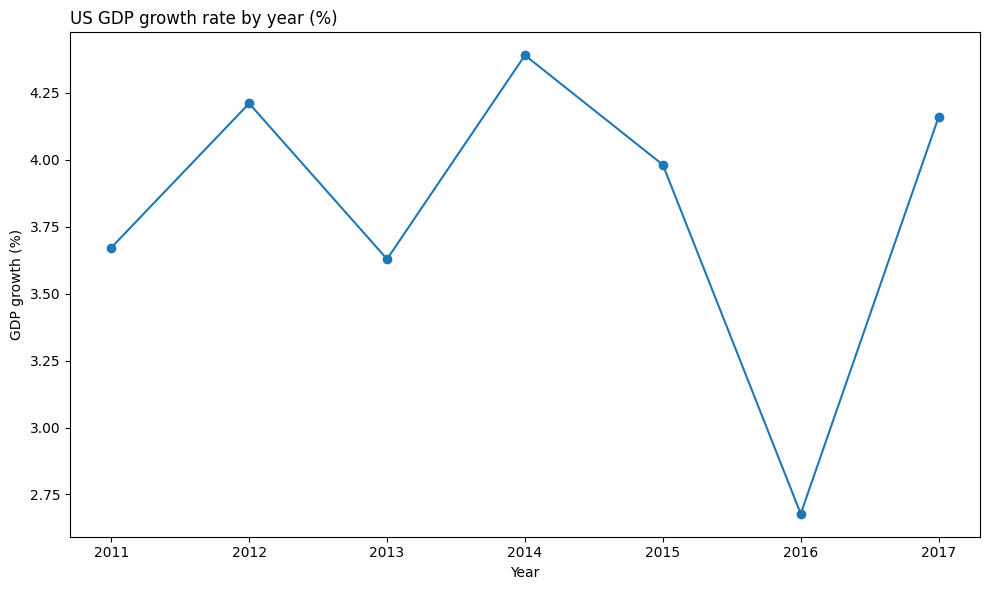

In [7]:
ax = us.plot(x='Year', y='GDP_growth_pct', marker='o', legend=False)
ax.set_title('US GDP growth rate by year (%)')
ax.set_xlabel('Year')
ax.set_ylabel('GDP growth (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

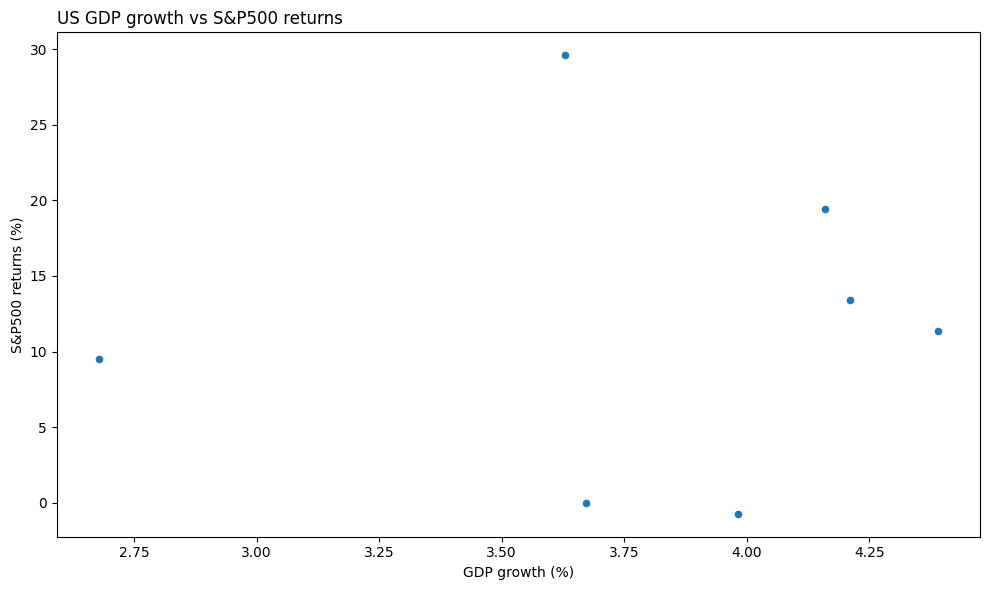

In [8]:
ax = us.plot(kind='scatter', x='GDP_growth_pct', y='SP500_Returns')
ax.set_title('US GDP growth vs S&P500 returns')
ax.set_xlabel('GDP growth (%)')
ax.set_ylabel('S&P500 returns (%)')
plt.tight_layout()
plt.show()

## 6. Kết luận ngắn

In [9]:
growth_2010_2018 = (
    macro.pivot(index='Country Name', columns='Year', values='GDP_per_capita')
         .assign(total_growth_pct=lambda d: (d[2018] / d[2010] - 1) * 100)
         [['total_growth_pct']]
         .sort_values('total_growth_pct', ascending=False)
)

top_pc_2018 = macro.loc[macro['Year'] == 2018, ['Country Name', 'GDP_per_capita']].sort_values('GDP_per_capita', ascending=False)
corr_value = us[['GDP_growth_pct', 'SP500_Returns']].corr().iloc[0, 1]

print('1) Mỹ vẫn là nền kinh tế lớn nhất trong mẫu 4 nước ở năm 2018.')
print('2) Xét GDP bình quân đầu người năm 2018, thứ hạng là:')
display(top_pc_2018)
print('3) Tăng trưởng GDP bình quân đầu người giai đoạn 2010-2018:')
display(growth_2010_2018)
print(f'4) Tương quan giữa GDP growth của Mỹ và S&P500 returns trong mẫu nhỏ này: {corr_value:.3f}')
print('   -> Giá trị này khá thấp, nên chưa thể kết luận hai biến đi cùng chiều trong bộ dữ liệu hiện có.')

1) Mỹ vẫn là nền kinh tế lớn nhất trong mẫu 4 nước ở năm 2018.
2) Xét GDP bình quân đầu người năm 2018, thứ hạng là:


,Country Name,GDP_per_capita
35,United States,62641.014570
17,Germany,48195.588453
26,Japan,39286.772766
8,China,9770.881650


3) Tăng trưởng GDP bình quân đầu người giai đoạn 2010-2018:


Year,total_growth_pct
Country Name,
China,114.723405
United States,29.244734
Germany,15.340458
Japan,-11.730373


4) Tương quan giữa GDP growth của Mỹ và S&P500 returns trong mẫu nhỏ này: 0.052
   -> Giá trị này khá thấp, nên chưa thể kết luận hai biến đi cùng chiều trong bộ dữ liệu hiện có.
